In [487]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("/content/co2.xlsx")

# Standardize column names
df.columns = ["Timestamp", "CO_Level"]

# Clean Timestamp column (strip spaces, drop blanks)
df["Timestamp"] = df["Timestamp"].astype(str).str.strip()
df = df[df["Timestamp"].notnull() & (df["Timestamp"] != "")]

# Convert to datetime (force errors to NaT, then drop)
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.dropna(subset=["Timestamp"])

# Ensure CO_Level is numeric
df["CO_Level"] = pd.to_numeric(df["CO_Level"], errors="coerce")

print(df.head(5))
print(df.info())

            Timestamp  CO_Level
1 2022-01-01 01:00:00      5.36
2 2022-01-01 02:00:00      5.33
3 2022-01-01 03:00:00      5.38
4 2022-01-01 04:00:00      5.46
5 2022-01-01 05:00:00      5.04
<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 1 to 8760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  8760 non-null   datetime64[ns]
 1   CO_Level   6770 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 205.3 KB
None


In [488]:
print(df.isnull().sum())

Timestamp       0
CO_Level     1990
dtype: int64


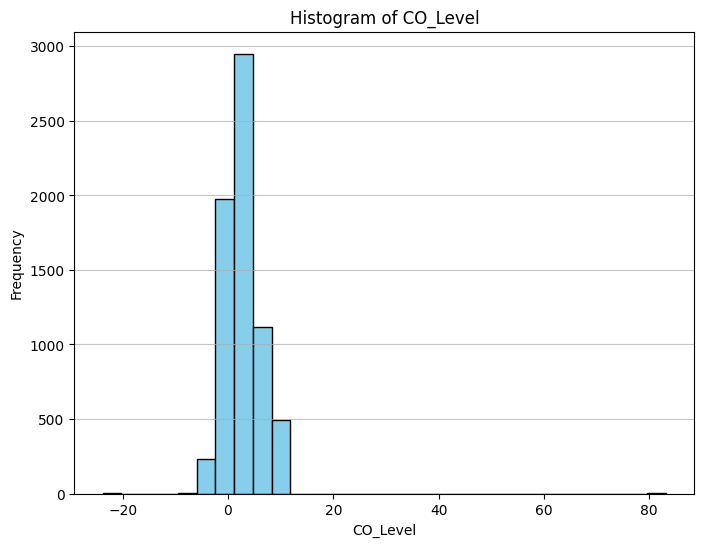

In [489]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: assume you already have a DataFrame called df
# Replace 'column_name' with the actual column you want to plot
column_name = "CO_Level"

plt.figure(figsize=(8,6))
plt.hist(df[column_name], bins=30, color="skyblue", edgecolor="black")
plt.title(f"Histogram of {column_name}")
plt.xlabel(column_name)
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()


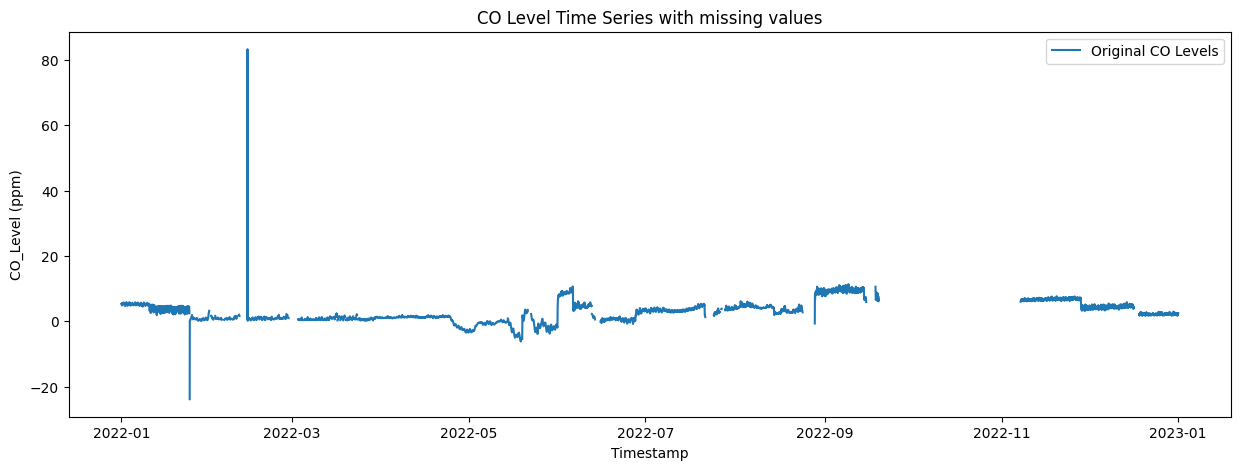

In [490]:
df.set_index("Timestamp", inplace=True)

plt.figure(figsize=(15,5))
plt.plot(df["CO_Level"], label="Original CO Levels")
# plt.plot(df_cleaned["CO_Level"], label="Cleaned CO Levels", color="green")
plt.title("CO Level Time Series with missing values")
plt.xlabel("Timestamp")
plt.ylabel("CO_Level (ppm)")
plt.legend()
plt.show()

In [491]:
df["CO_Level"] = df["CO_Level"].ffill().bfill()

Original dataset shape: (8760, 1)
Cleaned dataset shape: (8758, 1)
                     CO_Level
Timestamp                    
2022-01-01 01:00:00      5.36
2022-01-01 02:00:00      5.33
2022-01-01 03:00:00      5.38
2022-01-01 04:00:00      5.46
2022-01-01 05:00:00      5.04


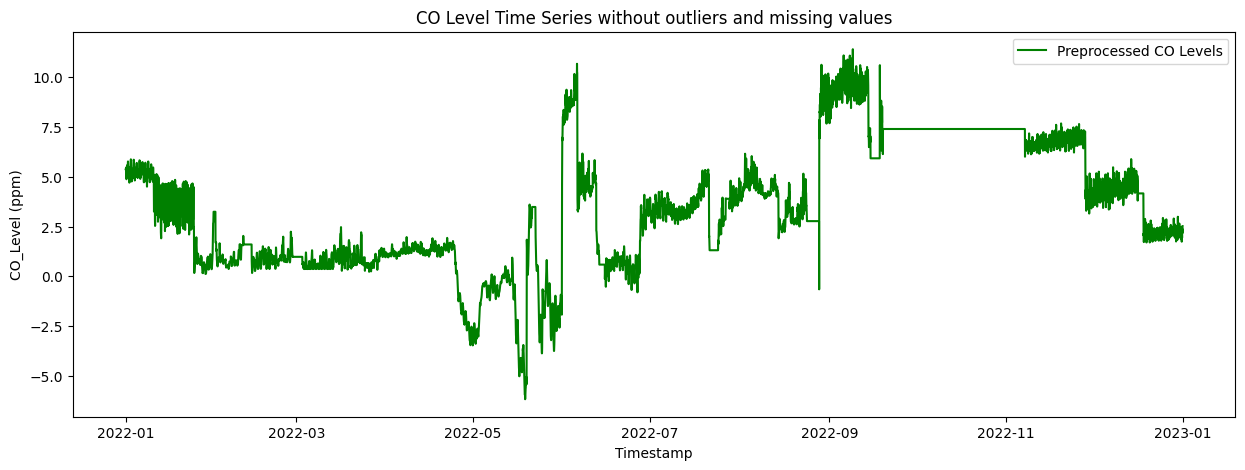

In [492]:
# Step 1: Compute Q1, Q3, and IQR
Q1 = df["CO_Level"].quantile(0.25)
Q3 = df["CO_Level"].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define bounds for non-outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter rows that are NOT outliers
df_cleaned = df[(df["CO_Level"] >= lower_bound) & (df["CO_Level"] <= upper_bound)]

# Step 4: Check result
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_cleaned.shape)
print(df_cleaned.head())

# Optional: visualize

plt.figure(figsize=(15,5))
# plt.plot(df["CO_Level"], label="CO Levels")
# # plt.plot(df_cleaned["CO_Level"], label="Cleaned CO Levels", color="green")
# plt.title("CO Level Time Series without missing values")
# plt.xlabel("Timestamp")
# plt.ylabel("CO_Level (ppm)")
# plt.legend()
# plt.show()
# plt.figure(figsize=(15,5))
# plt.plot(df["CO_Level"], label="Original CO Levels")
plt.plot(df_cleaned["CO_Level"], label="Preprocessed CO Levels", color="green")
plt.title("CO Level Time Series without outliers and missing values")
plt.xlabel("Timestamp")
plt.ylabel("CO_Level (ppm)")
plt.legend()
plt.show()

In [493]:
df=df_cleaned
print(df.head())
print(df.info())

                     CO_Level
Timestamp                    
2022-01-01 01:00:00      5.36
2022-01-01 02:00:00      5.33
2022-01-01 03:00:00      5.38
2022-01-01 04:00:00      5.46
2022-01-01 05:00:00      5.04
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8758 entries, 2022-01-01 01:00:00 to 2023-01-01 00:00:00
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CO_Level  8758 non-null   float64
dtypes: float64(1)
memory usage: 136.8 KB
None


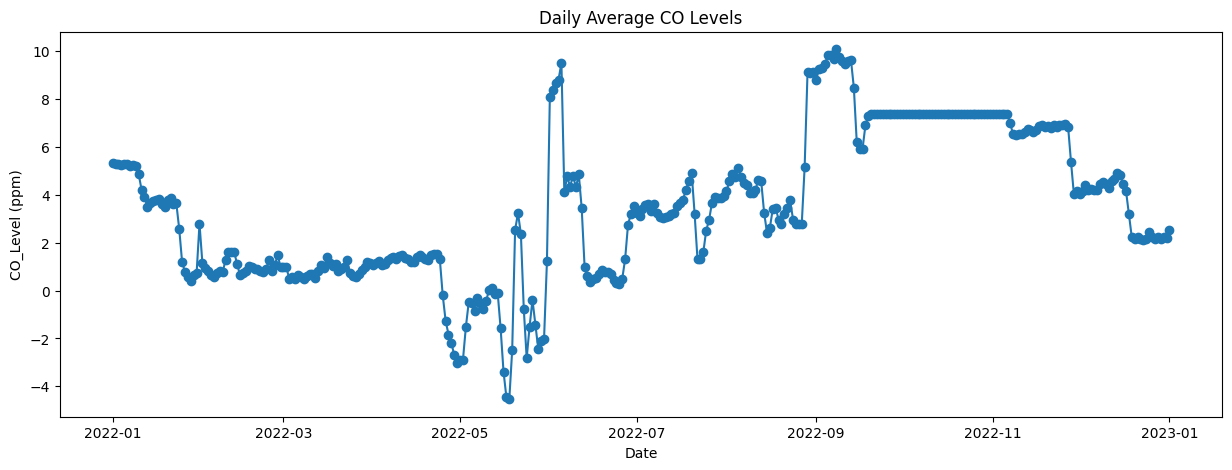

In [494]:
# Step 1: Set Timestamp as index
# df.set_index("Timestamp", inplace=True)

# Step 2: Resample to daily frequency and compute mean
df = df["CO_Level"].resample("D").mean()

# Step 3: Reset index if you want Timestamp as a column again
df = df.reset_index()


plt.figure(figsize=(15,5))
plt.plot(df["Timestamp"], df["CO_Level"], marker='o')
plt.title("Daily Average CO Levels")
plt.xlabel("Date")
plt.ylabel("CO_Level (ppm)")
plt.show()


In [495]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  366 non-null    datetime64[ns]
 1   CO_Level   366 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


,Timestamp,CO_Level
0,2022-01-01,5.340000
1,2022-01-02,5.269583
2,2022-01-03,5.293750
3,2022-01-04,5.246250
4,2022-01-05,5.272083


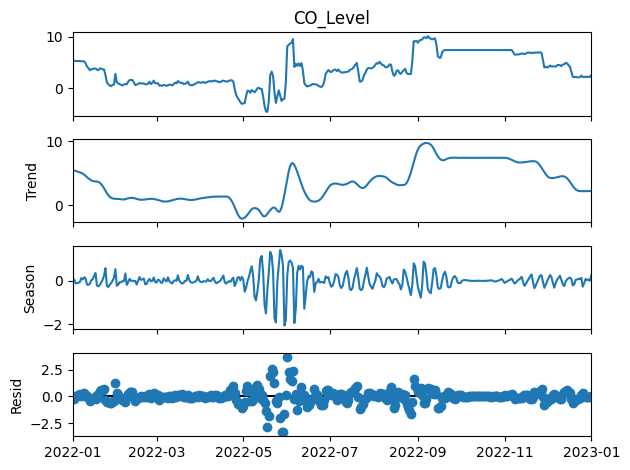

ADF Statistic: -6.489684351497461
p-value: 1.23554829472552e-08
ADF Statistic: -2.005344221740884
p-value: 0.2842347716438276


In [496]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

# STL decomposition
df_stl = df.set_index("Timestamp")
stl = STL(df_stl["CO_Level"])
res = stl.fit()

fig = res.plot()
plt.show()

# ADF test for stationarity
adf_result = adfuller(res.resid)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# ADF test for stationarity
adf_result = adfuller(df_stl["CO_Level"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])




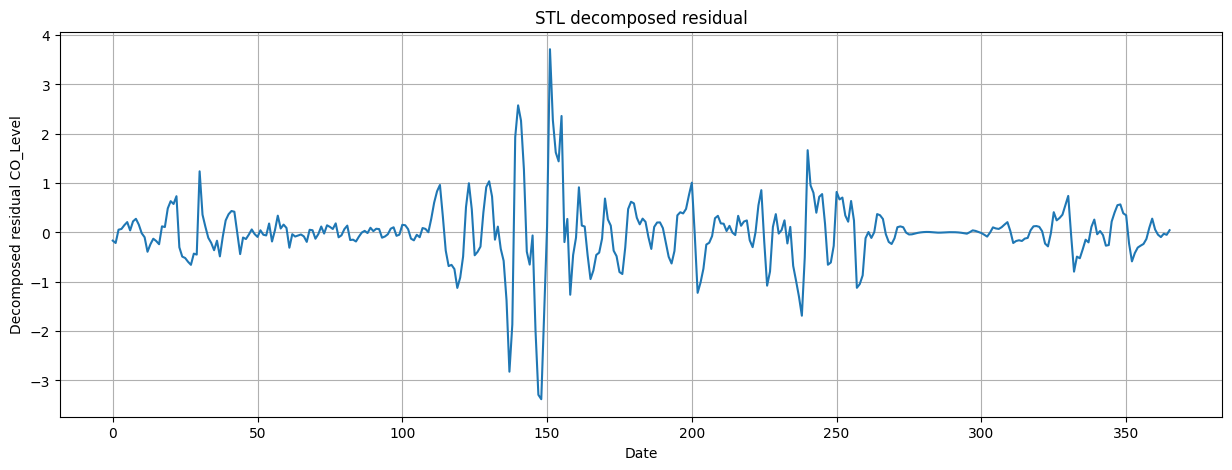

In [497]:
# Assuming df_daily has daily average CO levels
df=df.set_index("Timestamp")

# First-order differencing
df["CO_Level_diff"] = res.resid

# df["CO_Level_diff"] = res.resid
# Drop the first NaN value caused by differencing
df = df.dropna()

df=df.reset_index()
# Plot differenced series
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.index, df["CO_Level_diff"])
plt.title("STL decomposed residual")
plt.xlabel("Date")
plt.ylabel("Decomposed residual CO_Level")
plt.grid(True)
plt.show()


In [498]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["CO_Level_diff"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -6.489684351497461
p-value: 1.23554829472552e-08


In [499]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Timestamp      366 non-null    datetime64[ns]
 1   CO_Level       366 non-null    float64       
 2   CO_Level_diff  366 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 8.7 KB


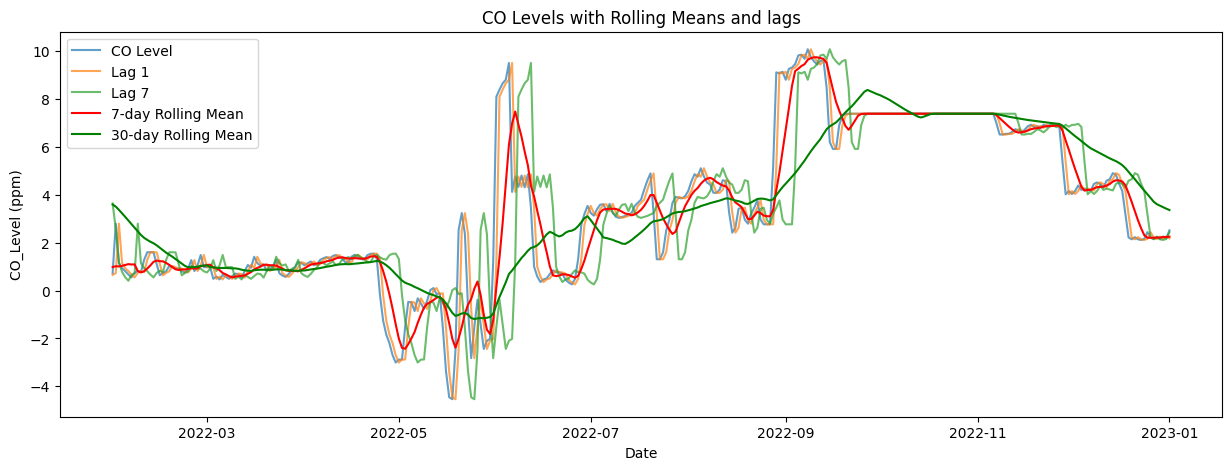

In [500]:
# ----------------------------
# 3.3 FEATURE ENGINEERING
# ----------------------------

# Ensure Timestamp is index
df = df.set_index("Timestamp")

# 1. Time-based features
df["day_of_week"] = df.index.dayofweek   # 0=Monday, 6=Sunday
df["month"] = df.index.month
df["day"] = df.index.day
df["year"] = df.index.year

# If you had hourly data, you could also add:
# df["hour"] = df.index.hour

# 2. Lag features
df["lag_1"] = df["CO_Level"].shift(1)   # Previous day
df["lag_7"] = df["CO_Level"].shift(7)   # Previous week

# 3. Rolling statistics
df["rolling_mean_7"] = df["CO_Level"].rolling(window=7).mean()
df["rolling_std_7"] = df["CO_Level"].rolling(window=7).std()

df["rolling_mean_30"] = df["CO_Level"].rolling(window=30).mean()
df["rolling_std_30"] = df["CO_Level"].rolling(window=30).std()

# Drop initial NaN values created by lag/rolling
df = df.dropna()



# ----------------------------
# Visualization of features
# ----------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.index, df["CO_Level"], label="CO Level", alpha=0.7)
plt.plot(df.index, df["lag_1"], label="Lag 1", alpha=0.7, )
plt.plot(df.index, df["lag_7"], label="Lag 7", alpha=0.7, )
plt.plot(df.index, df["rolling_mean_7"], label="7-day Rolling Mean", color="red")
plt.plot(df.index, df["rolling_mean_30"], label="30-day Rolling Mean", color="green")
plt.title("CO Levels with Rolling Means and lags")
plt.xlabel("Date")
plt.ylabel("CO_Level (ppm)")
plt.legend()
plt.show()

# Boxplot for day of week to see weekly seasonality
# import seaborn as sns
# plt.figure(figsize=(10,5))
# sns.boxplot(x="day_of_week", y="CO_Level", data=df.reset_index())
# plt.title("CO Levels by Day of Week")
# plt.xlabel("Day of Week (0=Mon, 6=Sun)")
# plt.ylabel("CO_Level (ppm)")
# plt.show()


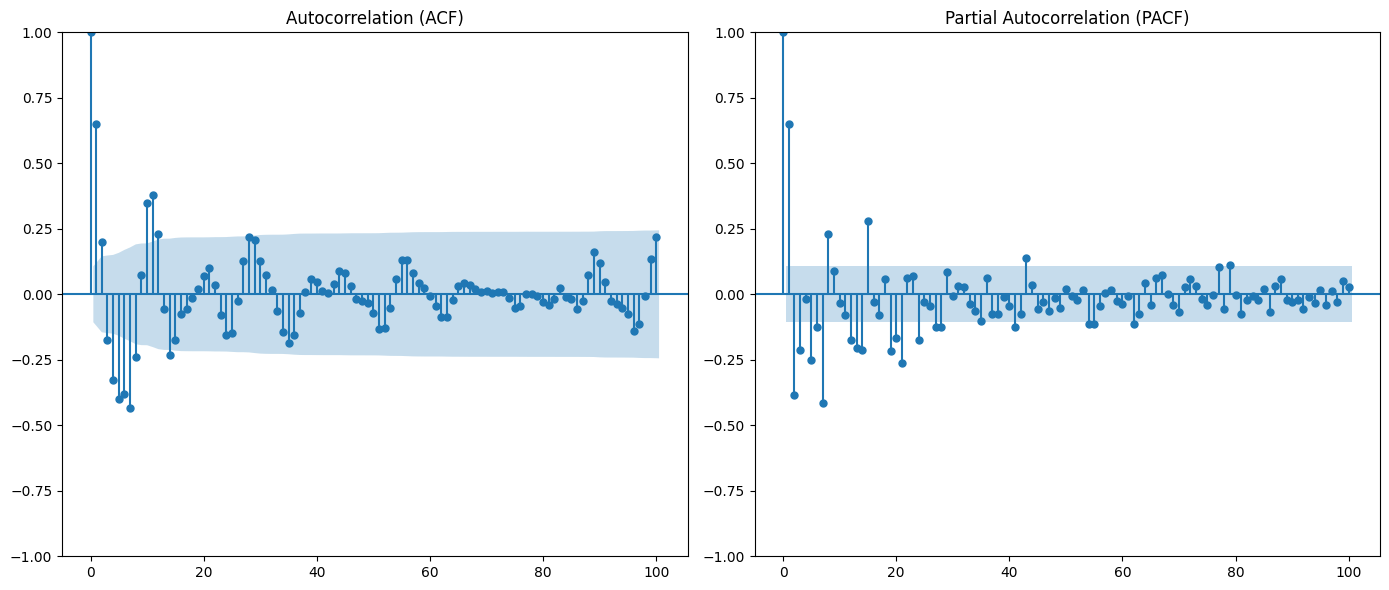

In [501]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Assume df has daily average CO levels
y = df["CO_Level_diff"]

plt.figure(figsize=(14,6))

# Autocorrelation Function (ACF)
plt.subplot(1,2,1)
plot_acf(y, lags=100, ax=plt.gca())
plt.title("Autocorrelation (ACF)")

# Partial Autocorrelation Function (PACF)
plt.subplot(1,2,2)
plot_pacf(y, lags=100, ax=plt.gca(), method="ywm")
plt.title("Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()


In [502]:
# !pip install pmdarima
# !pip install numpy==1.26.4
# from pmdarima import auto_arima

Training ARIMA...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Training Holt-Winters...
Training Random Forest...
              Actual     ARIMA  HoltWinters  RandomForest
Date                                                     
2022-10-26  0.030179  0.015630     0.041575      0.000783
2022-10-27  0.009976 -0.012245     0.041575      0.000783
2022-10-28 -0.012546 -0.029084     0.041575      0.000783
2022-10-29 -0.047085 -0.034393     0.041575      0.000783
2022-10-30 -0.084758 -0.030411     0.041575      0.000783


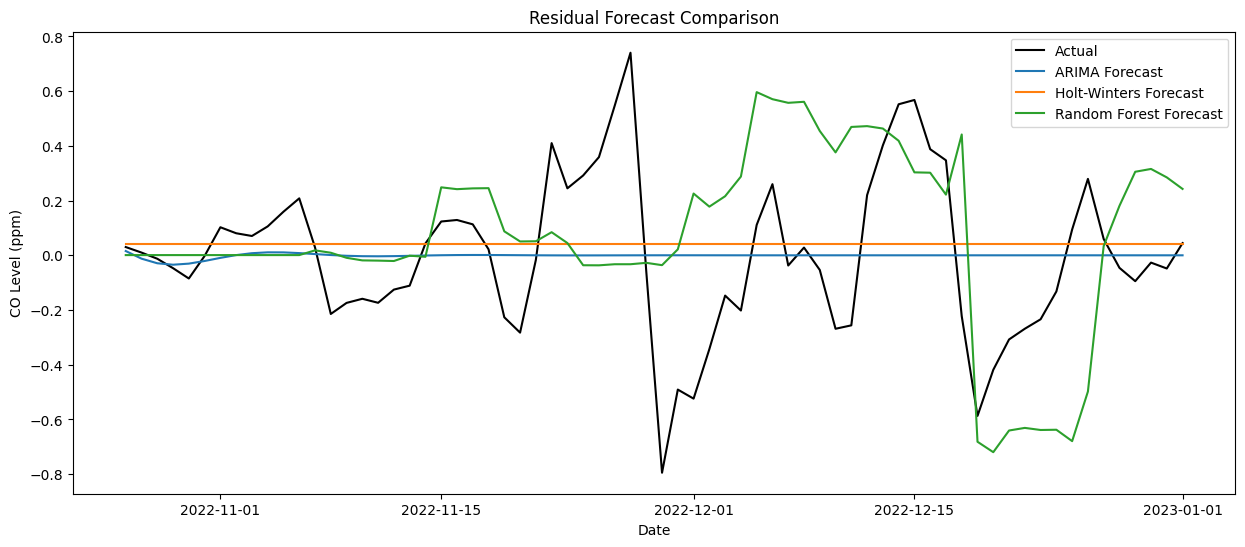

In [503]:
# ----------------------------
# 3.4 MODEL SELECTION & TRAINING
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ----------------------------
# Train-Test Split
# ----------------------------
# Assume df has daily CO_Level with features engineered
df = df.sort_index()

# Use last 20% as test set
split_index = int(len(df) * 0.8)
train, test = df.iloc[:split_index], df.iloc[split_index:]

y_train = train["CO_Level_diff"]
y_test = test["CO_Level_diff"]

# ----------------------------
# 1. ARIMA Model
# ----------------------------
print("Training ARIMA...")
arima_model = SARIMAX(y_train, order=(2,0,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(y_test))

# arima_fit=auto_arima(
#     y_train,
#     seasonal=False,       # allow seasonal differencing
#    # seasonal period (7 days here)
#     test="adf",          # use ADF test to check stationarity
#     d=None,              # let auto_arima determine differencing
#     D=None,              # let auto_arima determine seasonal differencing
#     trace=True,          # print search process
#     error_action="ignore",
#     suppress_warnings=True,
#     stepwise=True        # stepwise search is faster
# )

# print(arima_fit.summary())

# ----------------------------
# 2. Holt-Winters Exponential Smoothing
# ----------------------------
print("Training Holt-Winters...")

hw_model=hw_model=ExponentialSmoothing(y_train, initialization_method="estimated")
hw_fit = hw_model.fit(optimized=True)

hw_pred = hw_fit.forecast(len(y_test))

# ----------------------------
# 3. Random Forest Regressor (with lag & rolling features)
# ----------------------------
print("Training Random Forest...")
feature_cols = ["lag_1", "lag_7", "rolling_mean_7", "rolling_mean_30"]
X_train = train[feature_cols]
X_test = test[feature_cols]

rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# ----------------------------
# Collect results
# ----------------------------
results = pd.DataFrame({
    "Date": test.index,
    "Actual": y_test,
    "ARIMA": arima_pred.values,
    "HoltWinters": hw_pred.values,
    "RandomForest": rf_pred
}).set_index("Date")

print(results.head())

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(15,6))
plt.plot(results.index, results["Actual"], label="Actual", color="black")
plt.plot(results.index, results["ARIMA"], label="ARIMA Forecast")
plt.plot(results.index, results["HoltWinters"], label="Holt-Winters Forecast")
plt.plot(results.index, results["RandomForest"], label="Random Forest Forecast")
plt.legend()
plt.title("Residual Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("CO Level (ppm)")
plt.show()


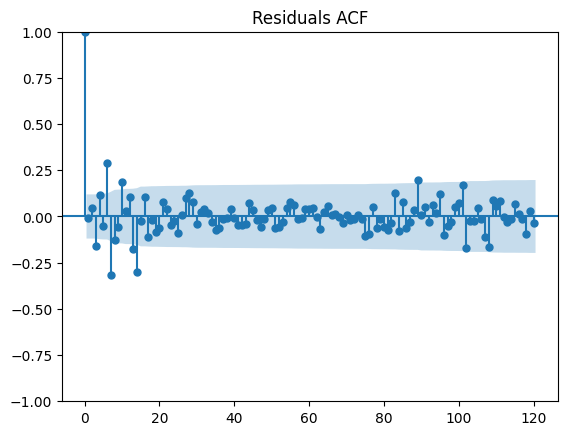

                               SARIMAX Results                                
Dep. Variable:          CO_Level_diff   No. Observations:                  269
Model:               SARIMAX(2, 0, 2)   Log Likelihood                -172.792
Date:                Sun, 07 Sep 2025   AIC                            355.583
Time:                        18:10:48   BIC                            373.557
Sample:                    01-30-2022   HQIC                           362.801
                         - 10-25-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4784      0.036     41.572      0.000       1.409       1.548
ar.L2         -0.7026      0.036    -19.598      0.000      -0.773      -0.632
ma.L1         -0.8611     10.176     -0.085      0.9

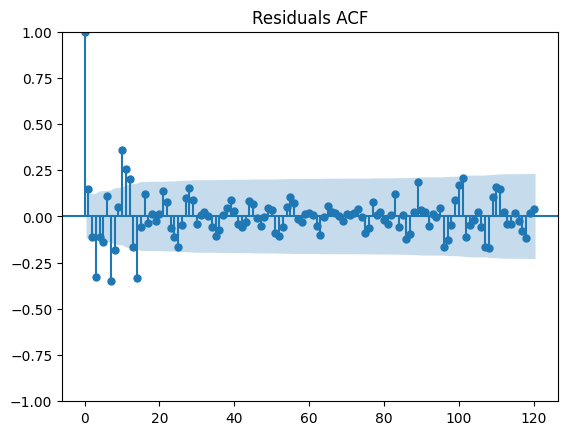

                       ExponentialSmoothing Model Results                       
Dep. Variable:            CO_Level_diff   No. Observations:                  269
Model:             ExponentialSmoothing   SSE                             99.400
Optimized:                         True   AIC                           -263.807
Trend:                             None   BIC                           -256.617
Seasonal:                          None   AICC                          -263.655
Seasonal Periods:                  None   Date:                 Sun, 07 Sep 2025
Box-Cox:                          False   Time:                         18:10:48
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
initial_level             -0.44968

In [504]:
residuals = arima_fit.resid
plot_acf(residuals, lags=120)
plt.title("Residuals ACF")
plt.show()

print(arima_fit.summary())

residuals = hw_fit.resid
plot_acf(residuals, lags=120)
plt.title("Residuals ACF")
plt.show()

print(hw_fit.summary())

                   MAE      RMSE
ARIMA         0.209839  0.279138
HoltWinters   0.215040  0.282679
RandomForest  0.289193  0.367487


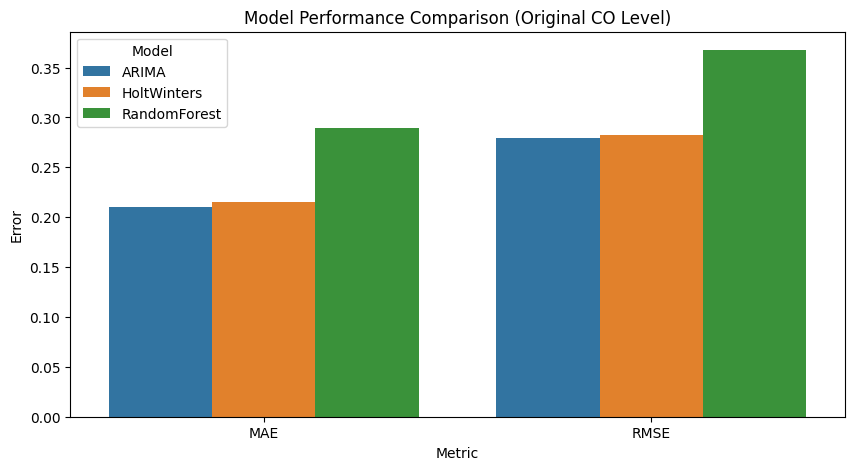

In [505]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Use results_real (already original scale)
metrics = {}
for model in ["ARIMA", "HoltWinters", "RandomForest"]:
    mae = mean_absolute_error(results["Actual"], results[model])
    rmse = np.sqrt(mean_squared_error(results["Actual"], results[model]))
    mape = mean_absolute_percentage_error(results["Actual"], results[model])

    metrics[model] = {"MAE": mae, "RMSE": rmse}

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(
    data=metrics_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value"),
    x="Metric", y="Value", hue="index"
)
plt.title("Model Performance Comparison (Original CO Level)")
plt.ylabel("Error")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.show()

In [506]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 337 entries, 2022-01-30 to 2023-01-01
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CO_Level         337 non-null    float64
 1   CO_Level_diff    337 non-null    float64
 2   day_of_week      337 non-null    int32  
 3   month            337 non-null    int32  
 4   day              337 non-null    int32  
 5   year             337 non-null    int32  
 6   lag_1            337 non-null    float64
 7   lag_7            337 non-null    float64
 8   rolling_mean_7   337 non-null    float64
 9   rolling_std_7    337 non-null    float64
 10  rolling_mean_30  337 non-null    float64
 11  rolling_std_30   337 non-null    float64
dtypes: float64(8), int32(4)
memory usage: 29.0 KB


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-650364690.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["rolling_mean_7"] = train["resid_diff"].rolling(window=7).mean

              Actual     ARIMA  HoltWinters  RandomForest
Timestamp                                                
2022-10-26  7.390000  7.377647     7.401396           NaN
2022-10-27  7.390000  7.371246     7.421599           NaN
2022-10-28  7.390000  7.376988     7.444122           NaN
2022-10-29  7.390000  7.405387     7.478660           NaN
2022-10-30  7.390000  7.445775     7.516333           NaN
...              ...       ...          ...           ...
2022-12-23  2.116667  2.350480     2.392056      2.469947
2022-12-24  2.161250  2.293379     2.334954      2.347343
2022-12-25  2.442917  2.348582     2.390157      2.503836
2022-12-26  2.219167  1.939900     1.981474      1.977753
2022-12-27  2.156667  2.097141     2.138715      2.293800

[63 rows x 4 columns]


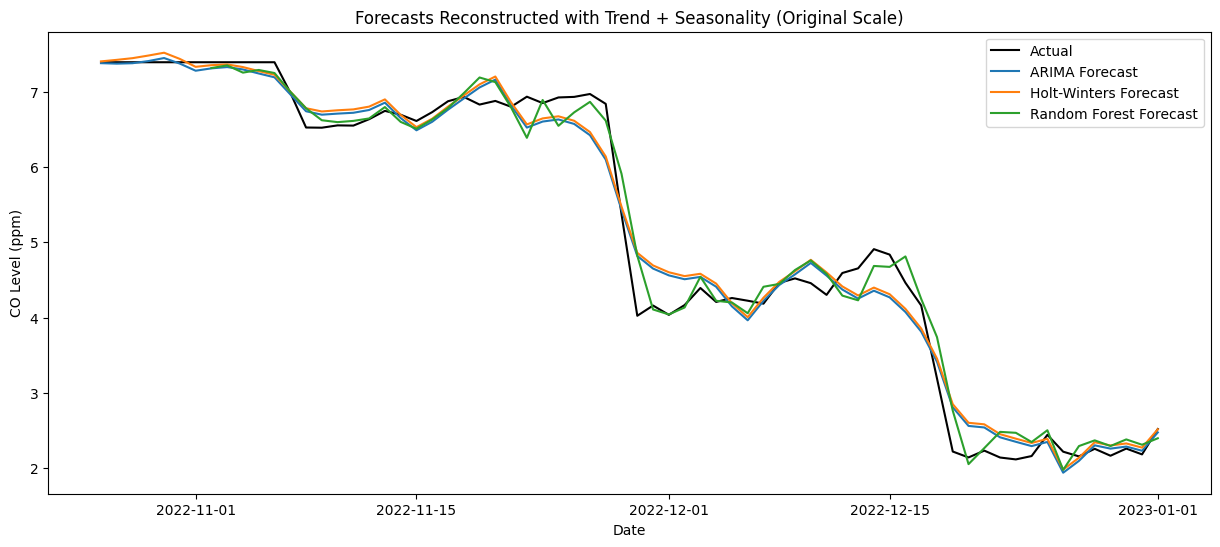

                   MAE      RMSE      MAPE
ARIMA         0.209871  0.279181  5.055122
HoltWinters   0.215040  0.282679  5.282048
RandomForest  0.180741  0.244424  4.643877


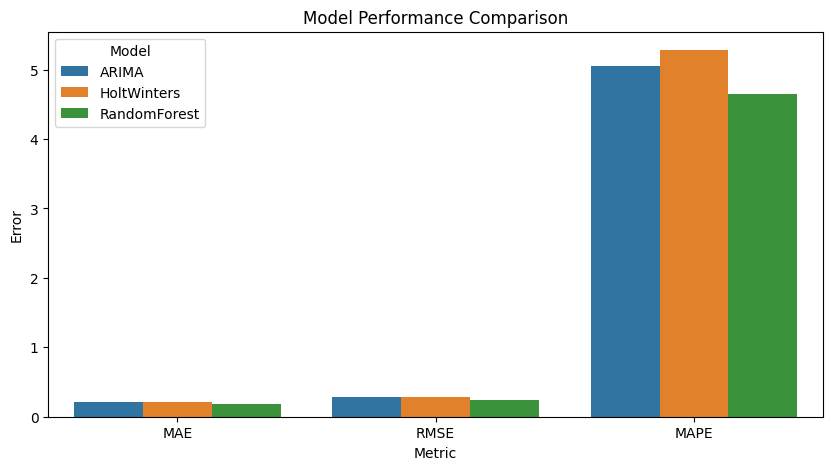

In [507]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# 1. STL decomposition on original daily data
# ----------------------------

stl = STL(df["CO_Level"])  # weekly seasonality for daily data
res = stl.fit()

df_stl["trend"] = res.trend
df_stl["seasonal"] = res.seasonal
# df_stl["resid"] = res.resid

# Differencing residuals (to make stationary)
# df_stl["resid_diff"] = df["CO_Level"].diff()
df_stl["resid_diff"] = res.resid

# Drop NA from differencing
df_stl = df_stl.dropna()

# ----------------------------
# 2. Train-test split (on differenced residuals)
# ----------------------------
split_index = int(len(df_stl) * 0.8)
train, test = df_stl.iloc[:split_index], df_stl.iloc[split_index:]

y_train = train["resid_diff"]
y_test = test["resid_diff"]

# ----------------------------
# 3. Train models on differenced residuals
# ----------------------------
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor

# ARIMA
arima_model = SARIMAX(y_train, order=(2,0,2))  # already differenced residuals
arima_fit = arima_model.fit()
arima_pred_diff = arima_fit.forecast(steps=len(y_test))

# Holt-Winters on residuals (rare, but possible)
hw_model = ExponentialSmoothing(y_train,initialization_method="estimated")
hw_fit = hw_model.fit()
hw_pred_diff = hw_fit.forecast(len(y_test))

# Random Forest with lag features on residuals

df["lag_1"] = df["CO_Level"].shift(1)   # Previous day
df["lag_7"] = df["CO_Level"].shift(7)   # Previous week

# 3. Rolling statistics
train["rolling_mean_7"] = train["resid_diff"].rolling(window=7).mean()
train["rolling_std_7"] = train["resid_diff"].rolling(window=7).std()

train["rolling_mean_30"] = train["resid_diff"].rolling(window=30).mean()
train["rolling_std_30"] = train["resid_diff"].rolling(window=30).std()


test["rolling_mean_7"] = test["resid_diff"].rolling(window=7).mean()
test["rolling_std_7"] = test["resid_diff"].rolling(window=7).std()

test["rolling_mean_30"] = test["resid_diff"].rolling(window=30).mean()
test["rolling_std_30"] = test["resid_diff"].rolling(window=30).std()

train["lag_1"] = train["resid_diff"].shift(1)
train["lag_7"] = train["resid_diff"].shift(7)
test["lag_1"] = test["resid_diff"].shift(1)
test["lag_7"] = test["resid_diff"].shift(7)

feature_cols = ["lag_1", "lag_7","rolling_mean_7", "rolling_std_7", ]
X_train, X_test = train[feature_cols].dropna(), test[feature_cols].dropna()
y_train_ml, y_test_ml = train["resid_diff"].loc[X_train.index], test["resid_diff"].loc[X_test.index]

rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train_ml)
rf_pred_diff = rf_model.predict(X_test)

# Align predictions with test index
arima_pred_diff = pd.Series(arima_pred_diff, index=y_test.index)
hw_pred_diff = pd.Series(hw_pred_diff, index=y_test.index)
rf_pred_diff = pd.Series(rf_pred_diff, index=X_test.index)

# ----------------------------
# 4. Reconstruct forecasts = residual_forecast + trend + seasonal
# ----------------------------
results_real = pd.DataFrame(index=test.index)
results_real["Actual"] = test["CO_Level"]

results_real["ARIMA"] = arima_pred_diff + test["trend"] + test["seasonal"]
results_real["HoltWinters"] = hw_pred_diff + test["trend"] + test["seasonal"]
results_real["RandomForest"] = rf_pred_diff + test.loc[X_test.index, "trend"] + test.loc[X_test.index, "seasonal"]

print(results_real.head(-5))

# ----------------------------
# 5. Visualization
# ----------------------------
plt.figure(figsize=(15,6))
plt.plot(results_real.index, results_real["Actual"], label="Actual", color="black")
plt.plot(results_real.index, results_real["ARIMA"], label="ARIMA Forecast")
plt.plot(results_real.index, results_real["HoltWinters"], label="Holt-Winters Forecast")
plt.plot(results_real.index, results_real["RandomForest"], label="Random Forest Forecast")
plt.legend()
plt.title("Forecasts Reconstructed with Trend + Seasonality (Original Scale)")
plt.xlabel("Date")
plt.ylabel("CO Level (ppm)")
plt.show()

# ----------------------------
# 6. Model Evaluation on Original Scale (NaN-safe)
# ----------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    y_true_masked = y_true[mask]
    y_pred_masked = y_pred[mask]
    nonzero_mask = y_true_masked != 0

    if nonzero_mask.sum() == 0:
        return np.nan
    return np.mean(
        np.abs((y_true_masked - y_pred_masked) / y_true_masked)
    ) * 100

# Compute metrics for each model (skip NaNs)
metrics = {}
for model in ["ARIMA", "HoltWinters", "RandomForest"]:
    mask = ~results_real["Actual"].isna() & ~results_real[model].isna()
    y_true = results_real.loc[mask, "Actual"]
    y_pred = results_real.loc[mask, model]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    metrics[model] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

# ----------------------------
# 7. Visualization of performance
# ----------------------------
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(
    data=metrics_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value"),
    x="Metric", y="Value", hue="index"
)
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

Forecasted CO Levels for Next Period:
            ARIMA_Forecast  HoltWinters_Forecast  RandomForest_Forecast
Date                                                                   
2023-01-02        1.980263              2.004013               1.955600
2023-01-03        2.105853              2.156206               2.112035
2023-01-04        2.289352              2.356486               2.319024
2023-01-05        2.234797              2.308070               2.258268
2023-01-06        2.261211              2.331769               2.290034
2023-01-07        2.211942              2.274155               2.242101
2023-01-08        2.465194              2.516950               2.486010
2023-01-09        1.961878              2.004013               1.967067
2023-01-10        2.120969              2.156206               2.116887
2023-01-11        2.324698              2.356486               2.316664
2023-01-12        2.276537              2.308070               2.265522
2023-01-13        2.298186

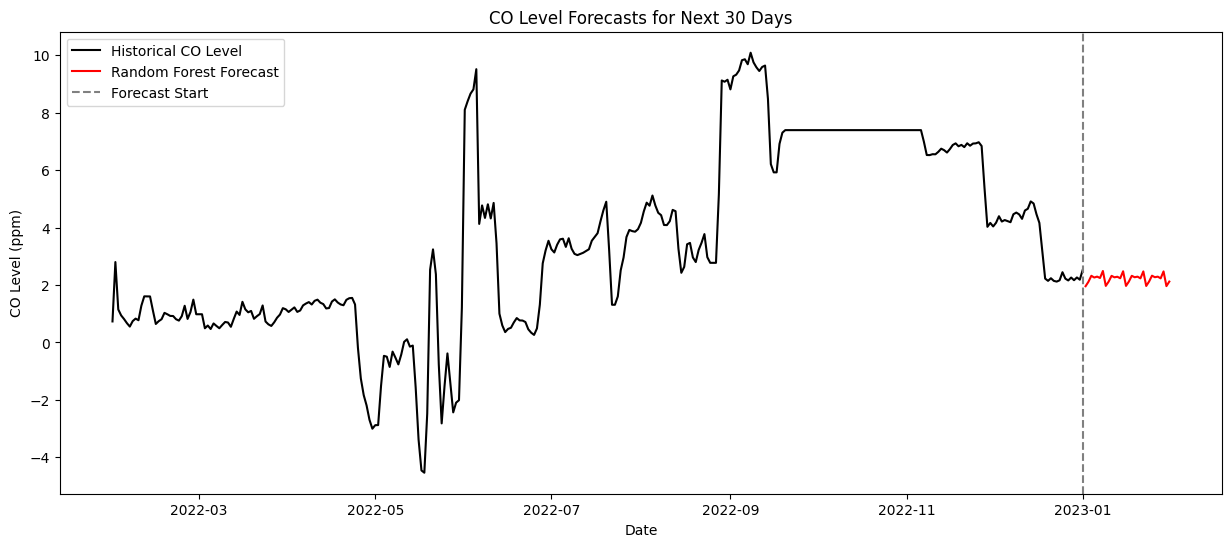

In [508]:
# ----------------------------
# 3.6 Forecasting Future CO Levels
# ----------------------------

import datetime

# 1️⃣ Decide forecast horizon
# e.g., next 30 days
forecast_days = 30

# 2️⃣ Forecast residuals for future periods

# --- ARIMA ---
arima_forecast_diff = arima_fit.forecast(steps=forecast_days)

# --- Holt-Winters ---
hw_forecast_diff = hw_fit.forecast(forecast_days)

# --- Random Forest ---
# For RF, we need to generate features recursively using previous residuals
last_train_index = df_stl.index[-1]
future_dates = pd.date_range(start=last_train_index + pd.Timedelta(days=1), periods=forecast_days, freq="D")

# Initialize list of residuals with last known residuals
resid_history = list(df_stl["resid_diff"].iloc[-max(30,7):])  # keep enough history for lag/rolling
rf_forecast_diff = []

for _ in range(forecast_days):
    # create features
    lag_1 = resid_history[-1]
    lag_7 = resid_history[-7] if len(resid_history) >= 7 else resid_history[0]

    rolling_mean_7 = np.mean(resid_history[-7:]) if len(resid_history) >= 7 else np.mean(resid_history)

    rolling_std_7 = np.std(resid_history[-7:]) if len(resid_history) >= 7 else np.std(resid_history)

    rolling_mean_30 = np.mean(resid_history[-30:]) if len(resid_history) >= 30 else np.mean(resid_history)

    rolling_std_30 = np.std(resid_history[-30:]) if len(resid_history) >= 30 else np.std(resid_history)

    X_feat = np.array([[lag_1, lag_7, rolling_mean_7, rolling_std_7,]])
    pred = rf_model.predict(X_feat)[0]
    rf_forecast_diff.append(pred)
    resid_history.append(pred)  # update history for next step

rf_forecast_diff = np.array(rf_forecast_diff)

# 3️⃣ Add trend and seasonal components to get forecasts on original scale
# Use last known trend and seasonal values and extend them (repeat last value)
last_trend = df_stl["trend"].iloc[-1]
last_seasonal = df_stl["seasonal"].iloc[-7:]  # assume weekly seasonality

# Repeat seasonal pattern if needed
seasonal_forecast = np.tile(last_seasonal, int(np.ceil(forecast_days)))[:forecast_days]

# Reconstruct forecasts
arima_forecast = arima_forecast_diff + last_trend + seasonal_forecast
hw_forecast = hw_forecast_diff + last_trend + seasonal_forecast
rf_forecast = rf_forecast_diff + last_trend + seasonal_forecast

# 4️⃣ Create forecast DataFrame
future_df = pd.DataFrame({
    "Date": future_dates,
    "ARIMA_Forecast": arima_forecast,
    "HoltWinters_Forecast": hw_forecast,
    "RandomForest_Forecast": rf_forecast
})
future_df.set_index("Date", inplace=True)

print("Forecasted CO Levels for Next Period:")
print(future_df)

# 5️⃣ Visualization
plt.figure(figsize=(15,6))
plt.plot(df_stl.index, df_stl["CO_Level"], label="Historical CO Level", color="black")
# plt.plot(future_df.index, future_df["ARIMA_Forecast"], label="ARIMA Forecast", color="blue")
# plt.plot(future_df.index, future_df["HoltWinters_Forecast"], label="Holt-Winters Forecast", color="green")
plt.plot(future_df.index, future_df["RandomForest_Forecast"], label="Random Forest Forecast", color="red")
plt.axvline(df_stl.index[-1], color="gray", linestyle="--", label="Forecast Start")
plt.xlabel("Date")
plt.ylabel("CO Level (ppm)")
plt.title("CO Level Forecasts for Next 30 Days")
plt.legend()
plt.show()
